# **Ninth LangGraph**

## **Boilerplate**

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

if os.environ["OPENAI_API_KEY"]:
    print("OpenAI api key set")
else:
    raise ValueError("OpenAI api key is not set")

OpenAI api key set


In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

## **Pydantic LLM Schema**

In [3]:
from pydantic import BaseModel, Field
from typing import List

class llm_schema(BaseModel):
    tasks: List[str] = Field(description="A list of tasks to be performed by the worker")

llm_with_schema = llm.with_structured_output(llm_schema)

llm_with_schema.invoke("What is the capital of france and what is the population of america")

llm_schema(tasks=['Provide the capital of France', 'Provide the population of America'])

## **Pydantic Graph Schema**

In [4]:
class graph_schema(BaseModel):
    
    tasks: List[str]
    query: str
    results: List[str]
    summary: str

## **Create Orchestrator Node**

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

def orchestrator(state: graph_schema) -> graph_schema:
    # fetch the user query
    user_query = state.query

    # create the prompt for llm
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "you are an orchestrator that breaks down a user query into tasks for the worker"),
            ("user", f"User query: {user_query}. Please generate one prompt per task for the worker to complete" )
        ]
    )

    # create the chain
    chain = prompt | llm_with_schema

    response = chain.invoke({"query": user_query})

    # update the task list
    state.tasks = response.tasks

    return state

## **Create Worker Node**

In [7]:
# execute function
def execute(query: str):

    response = llm.invoke(f"please execute this task: {query}")

    return response

In [ ]:
from concurrent.futures import ThreadPoolExecutor

# main worker node for generating parallel threads
def worker_node(state: graph_schema) -> graph_schema:

    tasks = state.tasks
    results = []

    with ThreadPoolExecutor(max_workers=len(tasks)) as executor:

        results_futures = executor.map(execute, tasks)
        for result in results_futures:
            results.append(result)

    state.results = results

    return state

## **Create Collector Node**

In [ ]:
def collector_node(state: graph_schema):

    results = state.results

    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a collector that summarizes the results from the worker"),
            ("user", f"Here are the results from the worker: {results}. Please summarize these results in a concise manner")
        ]
    )

    chain = prompt | llm

    summary = chain.invoke({"results": results})

    state.summary = summary

    return state

## **Create Graph and Execute**

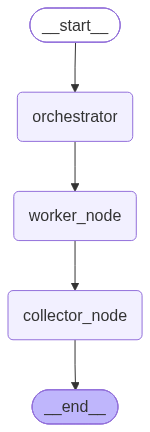

In [17]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("orchestrator", orchestrator)
graph.add_node("worker_node", worker_node)
graph.add_node("collector_node", collector_node)

graph.add_edge(START, "orchestrator")
graph.add_edge("orchestrator", "worker_node")
graph.add_edge("worker_node", "collector_node")
graph.add_edge("collector_node", END)

complex_graph = graph.compile()

# display graph
from IPython.display import Image, display

Image(complex_graph.get_graph().draw_mermaid_png())

## **Invoke the Graph**

In [19]:
complex_graph.invoke(
    {
        "query": "what is the capital of france and what is the population of america and what is the 6th digit of pi",
        "tasks": [],
        "results": [],
        "summary": ""
    }
)

TypeError: 'graph_schema' object is not subscriptable